In [33]:
import warnings
# Suppress the specific SciPy/NumPy version warnings
warnings.filterwarnings('ignore', message='.*NumPy version.*')

In [34]:
# %%
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Step 1: Loading Processed Data...")

DATA_PROCESSED = os.path.join("..", "data", "processed")
file_path = os.path.join(DATA_PROCESSED, "processed_all_households_blind.csv")

if not os.path.exists(file_path):
    raise FileNotFoundError(f"Missing {file_path}. Please run the 02_data_processing notebook first.")

df = pd.read_csv(file_path)
print(f"[SUCCESS] Loaded dataset: {df.shape[0]} households.")
print(f"[SUCCESS] Class Distribution:\n{df['TARGET_GAP'].value_counts(normalize=True)*100}")

Step 1: Loading Processed Data...
[SUCCESS] Loaded dataset: 61071 households.
[SUCCESS] Class Distribution:
TARGET_GAP
0    91.929066
1     8.070934
Name: proportion, dtype: float64


In [35]:
# %%
print("Step 2: Splitting Data (70% Train, 15% Validate, 15% Test)...")

# Define features (X) and target (y)
# We drop SERIALNO (ID) and PUMA (Geography) as they are not standard numerical proxies
X = df.drop(columns=['SERIALNO', 'PUMA', 'TARGET_GAP'])
y = df['TARGET_GAP']

# 1st Split: 70% Train, 30% Temporary Holdout (Val + Test)
# stratify=y ensures the small "Gap" class is distributed evenly across the splits
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# 2nd Split: Split the 30% holdout exactly in half (15% Validate, 15% Test)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"[SUCCESS] Training set:   {X_train.shape[0]} rows")
print(f"[SUCCESS] Validation set: {X_val.shape[0]} rows")
print(f"[SUCCESS] Test set:       {X_test.shape[0]} rows")

Step 2: Splitting Data (70% Train, 15% Validate, 15% Test)...
[SUCCESS] Training set:   42749 rows
[SUCCESS] Validation set: 9161 rows
[SUCCESS] Test set:       9161 rows


In [36]:
# %%
print("Step 3: Scaling Features and Training Baseline Model...")

# Features like NUM_CHILDREN (0-5) and GRPIP (Rent % 0-100) are on different scales.
# Logistic Regression requires them to be standardized.
scaler = StandardScaler()

# Fit the scaler ONLY on the training data to prevent data leakage from the validation/test sets
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Initialize the model
# class_weight='balanced' is critical here. Since the Gap is a minority class in the general population,
# this forces the model to heavily penalize missing a Gap household.
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

# Train the model
model.fit(X_train_scaled, y_train)

print("[SUCCESS] Logistic Regression Model trained successfully!")

Step 3: Scaling Features and Training Baseline Model...
[SUCCESS] Logistic Regression Model trained successfully!


Step 4: Evaluating on Validation Set...

--- Classification Report ---
                precision    recall  f1-score   support

Not in Gap (0)       0.97      0.74      0.84      8421
   The Gap (1)       0.20      0.74      0.31       740

      accuracy                           0.74      9161
     macro avg       0.58      0.74      0.58      9161
  weighted avg       0.91      0.74      0.80      9161

--- ROC-AUC Score ---
0.8109



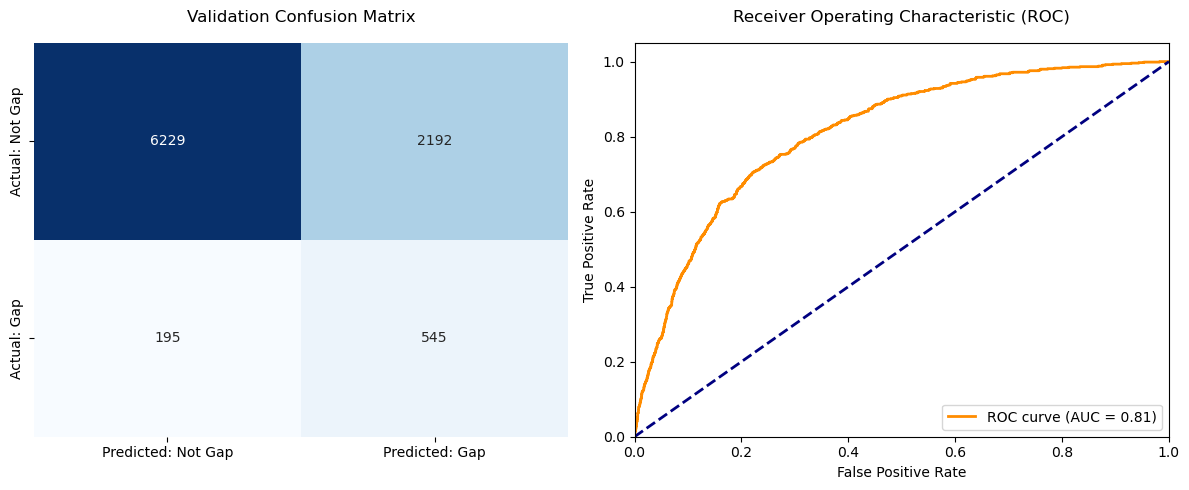

In [37]:
# %%
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

print("Step 4: Evaluating on Validation Set...")

# Predict classes (0 or 1) and probabilities (for ROC-AUC)
y_val_pred = model.predict(X_val_scaled)
y_val_probs = model.predict_proba(X_val_scaled)[:, 1] # Get probabilities for Class 1 (The Gap)

# 1. Classification Report
print("\n--- Classification Report ---")
# 0 = Not in Gap, 1 = The Gap
print(classification_report(y_val, y_val_pred, target_names=["Not in Gap (0)", "The Gap (1)"]))

# 2. ROC-AUC Score
auc_score = roc_auc_score(y_val, y_val_probs)
print(f"--- ROC-AUC Score ---\n{auc_score:.4f}\n")

# 3. Visualizations: Confusion Matrix & ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot A: Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=["Predicted: Not Gap", "Predicted: Gap"],
            yticklabels=["Actual: Not Gap", "Actual: Gap"], ax=axes[0])
axes[0].set_title('Validation Confusion Matrix', pad=15)

# Plot B: ROC Curve
fpr, tpr, thresholds = roc_curve(y_val, y_val_probs)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Diagonal random-guess line
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Receiver Operating Characteristic (ROC)', pad=15)
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

Step 5: Analyzing the Proxies (What predicts the Gap?)

POSITIVE Coefficients: Higher values in this feature INCREASE the likelihood of being in the Gap.
NEGATIVE Coefficients: Higher values in this feature DECREASE the likelihood of being in the Gap.



,Feature,Coefficient
9,GRPIP,0.456862
12,NP,0.331086
7,ACCESSINET,0.145128
5,IS_MINORITY_HH,0.084584
8,LNGI,0.064788
1,HAS_DISABLED,0.021554
6,VEH,-0.029187
11,TEN,-0.039844
10,RMSP,-0.052338
2,NUM_CHILDREN,-0.132597


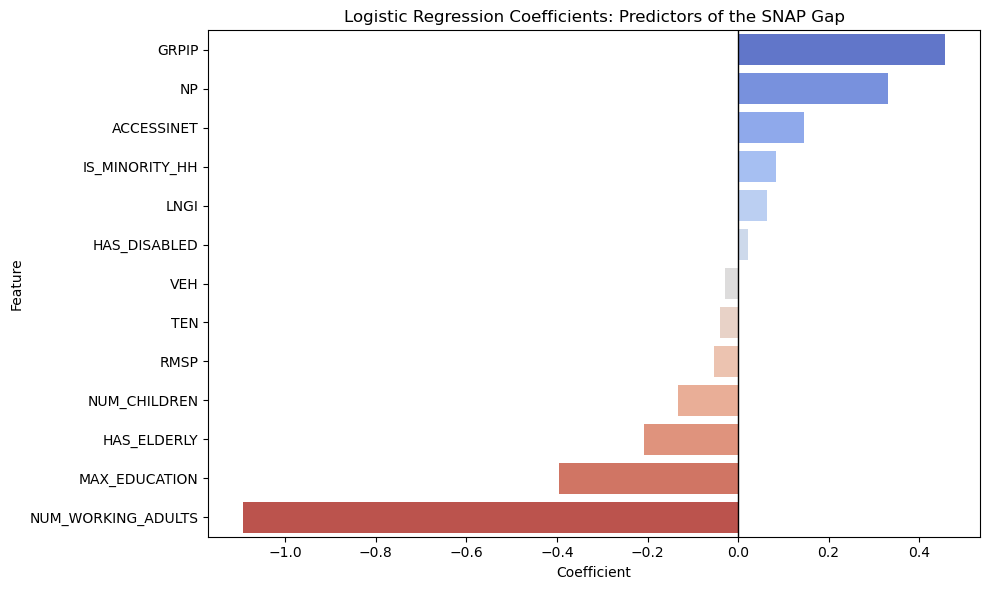

In [38]:
# %%
print("Step 5: Analyzing the Proxies (What predicts the Gap?)")

# Extract coefficients and map them back to the original feature names
coefficients = model.coef_[0]
feature_names = X.columns

# Create a clean DataFrame
df_coef = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort by impact
df_coef = df_coef.sort_values(by='Coefficient', ascending=False)

print("\nPOSITIVE Coefficients: Higher values in this feature INCREASE the likelihood of being in the Gap.")
print("NEGATIVE Coefficients: Higher values in this feature DECREASE the likelihood of being in the Gap.\n")

display(df_coef)

# Optional Visual Plot of the Coefficients
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=df_coef, hue='Feature', palette='coolwarm', legend=False)
plt.title('Logistic Regression Coefficients: Predictors of the SNAP Gap')
plt.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

In [39]:
# %%
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

print("[INIT] Step 6: Setting up Advanced Models and Validation Split...")

# To tune specifically on the validation set without cross-validation leakage,
# we combine the train and validation sets and use PredefinedSplit.
X_tune = np.vstack((X_train_scaled, X_val_scaled))
y_tune = np.concatenate((y_train, y_val))

# Create a list where -1 means "Training Data" and 0 means "Validation Data"
test_fold = [-1] * len(X_train_scaled) + [0] * len(X_val_scaled)
ps = PredefinedSplit(test_fold)

print("[SUCCESS] PredefinedSplit created. Training rows:", len(X_train_scaled), "| Validation rows:", len(X_val_scaled))

[INIT] Step 6: Setting up Advanced Models and Validation Split...
[SUCCESS] PredefinedSplit created. Training rows: 42749 | Validation rows: 9161


In [40]:
# %%
print("[PROCESS] Step 7: Tuning Random Forest Classifier...")

# Define the baseline model (balanced weights are critical here)
rf_base = RandomForestClassifier(class_weight='balanced', random_state=42)

# Define the hyperparameter grid to search
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Setup RandomizedSearch optimizing for ROC-AUC
rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_grid,
    n_iter=15,               # Number of random combinations to try
    scoring='roc_auc',       # Optimize for the area under the ROC curve
    cv=ps,                   # Use our explicit Validation set
    random_state=42,
    n_jobs=-1,               # Use all CPU cores
    verbose=1
)

rf_search.fit(X_tune, y_tune)

best_rf = rf_search.best_estimator_
print(f"\n[SUCCESS] Best Random Forest AUC on Validation: {rf_search.best_score_:.4f}")
print(f"[INFO] Best RF Parameters: {rf_search.best_params_}")

[PROCESS] Step 7: Tuning Random Forest Classifier...
Fitting 1 folds for each of 15 candidates, totalling 15 fits

[SUCCESS] Best Random Forest AUC on Validation: 0.8526
[INFO] Best RF Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10}


In [41]:
# %%
print("[PROCESS] Step 8: Tuning LightGBM Classifier...")

# LightGBM handles class imbalance using the 'is_unbalance' parameter
lgb_base = lgb.LGBMClassifier(is_unbalance=True, random_state=42, n_jobs=-1, verbose=-1)

# Define the hyperparameter grid
# LightGBM is prone to overfitting, so we control num_leaves and depth
lgb_param_grid = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [15, 31, 50],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

lgb_search = RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=lgb_param_grid,
    n_iter=20,               
    scoring='roc_auc',       
    cv=ps,                   
    random_state=42,
    verbose=1
)

lgb_search.fit(X_tune, y_tune)

best_lgb = lgb_search.best_estimator_
print(f"\n[SUCCESS] Best LightGBM AUC on Validation: {lgb_search.best_score_:.4f}")
print(f"[INFO] Best LGBM Parameters: {lgb_search.best_params_}")

[PROCESS] Step 8: Tuning LightGBM Classifier...
Fitting 1 folds for each of 20 candidates, totalling 20 fits

[SUCCESS] Best LightGBM AUC on Validation: 0.8556
[INFO] Best LGBM Parameters: {'subsample': 0.8, 'num_leaves': 31, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


In [44]:
# %%
print("[EVAL] Step 9: Comparing Champion Models on the Validation Set...")

# Calculate ROC-AUC for all three models using probabilities
y_val_probs_lr = model.predict_proba(X_val_scaled)[:, 1]
auc_lr = roc_auc_score(y_val, y_val_probs_lr)

y_val_probs_rf = best_rf.predict_proba(X_val_scaled)[:, 1]
auc_rf = roc_auc_score(y_val, y_val_probs_rf)

y_val_probs_lgb = best_lgb.predict_proba(X_val_scaled)[:, 1]
auc_lgb = roc_auc_score(y_val, y_val_probs_lgb)

print("\n--- ROC-AUC Comparison ---")
print(f"Logistic Regression: {auc_lr:.4f}")
print(f"Random Forest:       {auc_rf:.4f}")
print(f"LightGBM:            {auc_lgb:.4f}")

# Automatically identify the winner and extract its parameters
models_dict = {'Logistic Regression': auc_lr, 'Random Forest': auc_rf, 'LightGBM': auc_lgb}
champion_name = max(models_dict, key=models_dict.get)

print(f"\n[CHAMPION] The best performing model is: {champion_name}")

# Assign the champion model to a generic variable for Step 10 and print its parameters
if champion_name == 'Random Forest':
    champion_model = best_rf
    print(f"[INFO] Winning Parameters: {rf_search.best_params_}")
elif champion_name == 'LightGBM':
    champion_model = best_lgb
    print(f"[INFO] Winning Parameters: {lgb_search.best_params_}")
else:
    champion_model = model
    print("[INFO] Baseline Logistic Regression remains the champion.")

[EVAL] Step 9: Comparing Champion Models on the Validation Set...

--- ROC-AUC Comparison ---
Logistic Regression: 0.8109
Random Forest:       0.8897
LightGBM:            0.8732

[CHAMPION] The best performing model is: Random Forest
[INFO] Winning Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10}



[ANALYSIS] Step 10: Extracting Feature Importances from Random Forest...

[INFO] Top Predictors of the SNAP Gap according to Random Forest:


,Feature,Importance
9,GRPIP,0.268275
3,NUM_WORKING_ADULTS,0.244561
4,MAX_EDUCATION,0.145391
12,NP,0.067884
11,TEN,0.065326
6,VEH,0.052679
10,RMSP,0.049480
7,ACCESSINET,0.027272
0,HAS_ELDERLY,0.027033
2,NUM_CHILDREN,0.021783


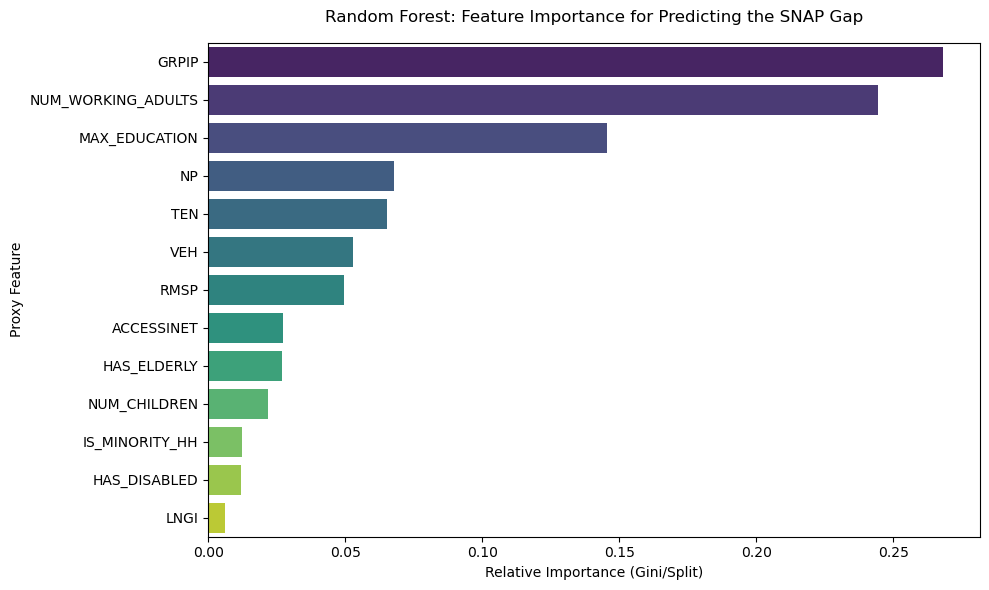

In [45]:
# %%
print(f"\n[ANALYSIS] Step 10: Extracting Feature Importances from {champion_name}...")

# Check if the champion is a tree-based model (LR doesn't have feature_importances_)
if champion_name in ['Random Forest', 'LightGBM']:
    # Extract importances
    importances = champion_model.feature_importances_
    
    # Create a DataFrame for clean display
    df_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importances
    })
    
    # Sort from most important to least
    df_importance = df_importance.sort_values(by='Importance', ascending=False)
    
    print(f"\n[INFO] Top Predictors of the SNAP Gap according to {champion_name}:")
    display(df_importance)

    # Plot the Feature Importances
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x='Importance', 
        y='Feature', 
        data=df_importance, 
        hue='Feature', 
        palette='viridis', 
        legend=False
    )
    plt.title(f'{champion_name}: Feature Importance for Predicting the SNAP Gap', pad=15)
    plt.xlabel('Relative Importance (Gini/Split)')
    plt.ylabel('Proxy Feature')
    plt.tight_layout()
    plt.show()

else:
    print("[INFO] Champion is Logistic Regression. Please refer to the Step 5 Coefficients plot.")

[INIT] Step 11: Calculating SHAP Values for Directional Impact...
[SUCCESS] SHAP values calculated. Generating Summary Plot...


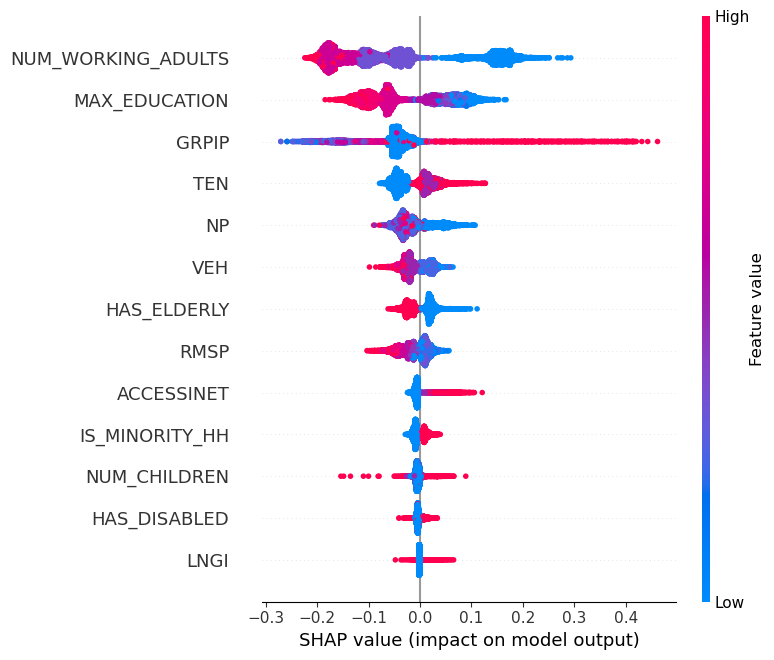

In [47]:
# %%
import shap

print("[INIT] Step 11: Calculating SHAP Values for Directional Impact...")

# Convert the scaled numpy array back to a DataFrame so our plot has clean feature names
X_val_df = pd.DataFrame(X_val_scaled, columns=X.columns)

# Initialize the SHAP explainer specifically optimized for Tree models
explainer = shap.TreeExplainer(champion_model)

# Calculate SHAP values for the validation set. 
# (This may take 10-30 seconds depending on your CPU)
shap_values = explainer.shap_values(X_val_df)

# Random Forest binary classification returns SHAP values for both classes [Class 0, Class 1]
# We only care about what pushes people into Class 1 (The Gap)
if isinstance(shap_values, list):
    shap_values_gap = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_values_gap = shap_values[:, :, 1]
else:
    shap_values_gap = shap_values

print("[SUCCESS] SHAP values calculated. Generating Summary Plot...")

# Generate the beautiful SHAP Summary Plot
shap.summary_plot(shap_values_gap, X_val_df, plot_type="dot")


[INIT] Step 12: Final Unbiased Evaluation on the Test Set...
[SUCCESS] FINAL TEST ROC-AUC: 0.8659

[INFO] Final Classification Report (Test Set):
                precision    recall  f1-score   support

Not in Gap (0)       0.97      0.82      0.89      8422
   The Gap (1)       0.26      0.75      0.39       739

      accuracy                           0.81      9161
     macro avg       0.62      0.78      0.64      9161
  weighted avg       0.92      0.81      0.85      9161

[INFO] Generating Final Test Confusion Matrix...


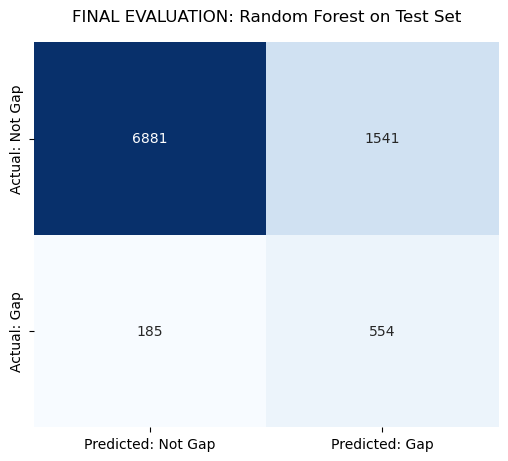

In [48]:
# %%
print("\n[INIT] Step 12: Final Unbiased Evaluation on the Test Set...")

# 1. Predict classes and probabilities using the Champion Model on the unseen TEST data
y_test_pred = champion_model.predict(X_test_scaled)
y_test_probs = champion_model.predict_proba(X_test_scaled)[:, 1]

# 2. Calculate Final ROC-AUC
final_auc = roc_auc_score(y_test, y_test_probs)

print("==================================================")
print(f"[SUCCESS] FINAL TEST ROC-AUC: {final_auc:.4f}")
print("==================================================\n")

# 3. Print Final Classification Report
print("[INFO] Final Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred, target_names=["Not in Gap (0)", "The Gap (1)"]))

# 4. Visual Confusion Matrix for the Test Set
print("[INFO] Generating Final Test Confusion Matrix...")
cm_test = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=["Predicted: Not Gap", "Predicted: Gap"],
            yticklabels=["Actual: Not Gap", "Actual: Gap"])
plt.title(f'FINAL EVALUATION: {champion_name} on Test Set', pad=15)
plt.show()